# Quantum Teleportation

Quantum Teleportation is a protocol that transfers an unknown quantum state from Alice to Bob using a shared entangled qubit pair and classical communication.

In this experiment, we implement quantum teleportation on real IBM Quantum hardware. We first demonstrate the protocol using nearby qubits and then extend it by using SWAP operations to separate Alice and Bob's entangled qubits across the processor.

The experiment verifies that the quantum state can be reconstructed at Bob's qubit, provided that Alice and Bob share entanglement and Alice's measurement results are communicated through a classical channel.

## 1. Standard Quantum Teleportation

We begin by constructing the quantum teleportation circuit.

- `Q` is the unknown quantum state to be teleported.
- `A` is Alice's qubit.
- `B` is Bob's qubit.
- Alice and Bob first share an entangled Bell pair.
- Alice then performs a joint operation and measurement on her two qubits.
- The measurement results are stored in classical bits and used to apply the required corrections to Bob's qubit.

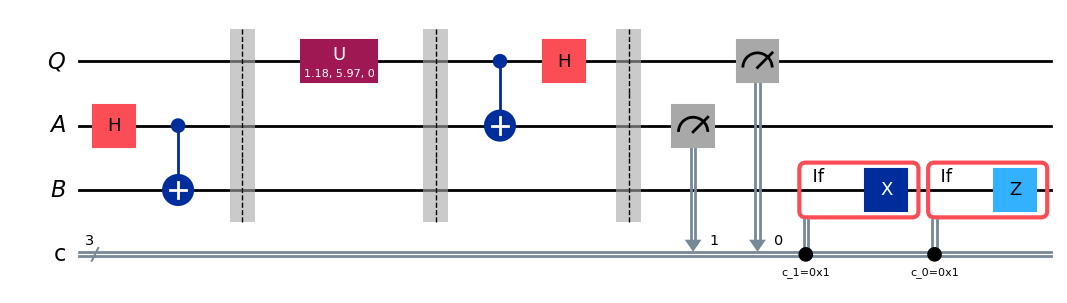

In [1]:
# Step 1: Map your problem to a quantum circuit

# Import some general packages
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
import numpy as np

# Define registers
secret = QuantumRegister(1, "Q")
Alice = QuantumRegister(1, "A")
Bob = QuantumRegister(1, "B")

cr = ClassicalRegister(3, "c")

qc = QuantumCircuit(secret, Alice, Bob, cr)

# We entangle Alice's and Bob's qubits as in our work above.
# We apply a Hadamard gate and then a CNOT gate.
qc.h(Alice)
qc.cx(Alice, Bob)

qc.barrier()

# Now we will use random variables to create the secret state.
np.random.seed(42)  # fixing seed for repeatability
theta = np.random.uniform(0.0, 1.0) * np.pi  # from 0 to pi
varphi = np.random.uniform(0.0, 2.0) * np.pi  # from 0 to 2*pi

# Assign the secret state to the qubit on the other side of Alice's (qubit 0), labeled Q
qc.u(theta, varphi, 0.0, secret)
qc.barrier()

# Now we entangle Q and Alice's qubits as in the discussion above.
qc.cx(secret, Alice)
qc.h(secret)
qc.barrier()

# Now Alice measures her qubits, and stores the outcomes in the "classical registers" cr[]
qc.measure(Alice, cr[1])
qc.measure(secret, cr[0])

# Now we insert some conditional logic. If Alice measures Q in a "1" we need a Z gate, and if Alice
# measures A in a "1" we need an X gate
with qc.if_test((cr[1], 1)):
    qc.x(Bob)
with qc.if_test((cr[0], 1)):
    qc.z(Bob)

qc.draw(output="mpl")

### Verifying the Teleported State

To verify that Bob's qubit contains the original state, we apply the inverse of the state-preparation unitary.

If teleportation is successful, this operation should return Bob's qubit to `|0⟩` before measurement.

Therefore, a high probability of measuring `0` indicates successful teleportation.

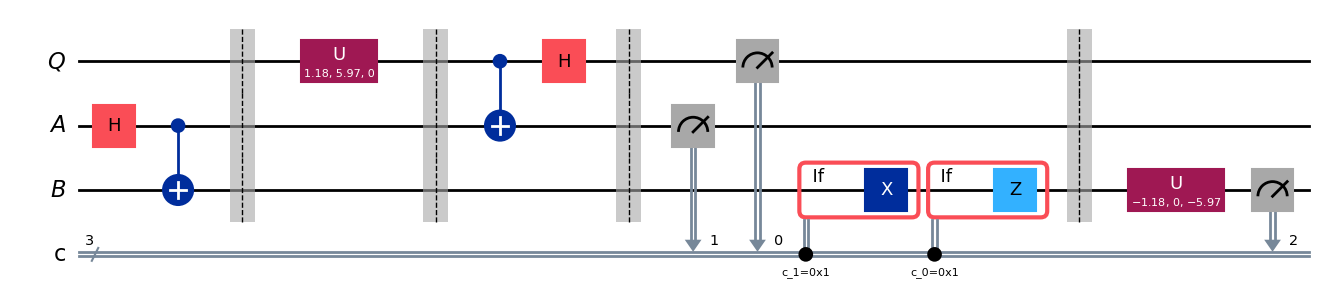

In [2]:
# Add the inverse of U and measure Bob's qubit.
qc.barrier()

qc.u(theta, varphi, 0.0, Bob).inverse()  # inverse of u(theta,varphi,0.0)
qc.measure(Bob, cr[2])  # add measurement gate

qc.draw(output="mpl")

### Running on Real IBM Quantum Hardware

The circuit is now submitted to an actual IBM Quantum processor rather than an ideal simulator.

The least-busy available backend is selected to execute the experiment.

In [3]:
# Load IBM Quantum Compute Service
from qiskit_ibm_runtime import QiskitRuntimeService

# Load IBM Quantum Compute Service

# Load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_brisbane")
print(backend.name)

ibm_fez


### Transpilation

Before execution, the circuit is transpiled to match the native gates and connectivity of the selected IBM Quantum processor.

This step maps the abstract circuit onto the physical qubits and operations supported by the hardware.

In [4]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

In [5]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

In [6]:
job = sampler.run([qc_isa])
# job = sampler_sim.run([qc_isa])
res = job.result()
counts = res[0].data.c.get_counts()

### Hardware Results

The measurement results from the real quantum processor are visualized as a histogram.

The dominant `0` outcome after applying the inverse state-preparation operation indicates that Bob's qubit successfully reproduced the teleported quantum state.

The occasional `1` outcomes represent errors introduced by the real quantum hardware.

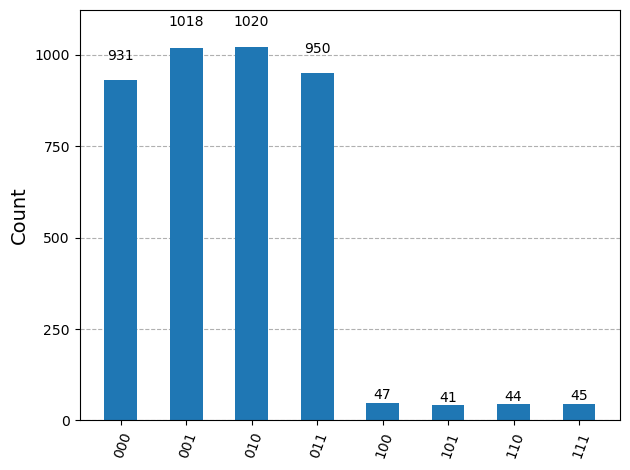

In [7]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

# 2. Teleportation Across a Processor

The teleportation protocol does not require Alice and Bob's entangled qubits to be physically adjacent.

Here, we use SWAP operations to move the entangled qubits apart across the processor while preserving their quantum information. We then perform the same teleportation protocol between the distant qubits.

### Moving the Entangled Qubits Apart

Alice and Bob initially create an entangled pair.

SWAP operations are then used to move their respective quantum states toward opposite sides of the processor. This allows us to investigate teleportation when the entangled qubits are physically separated.

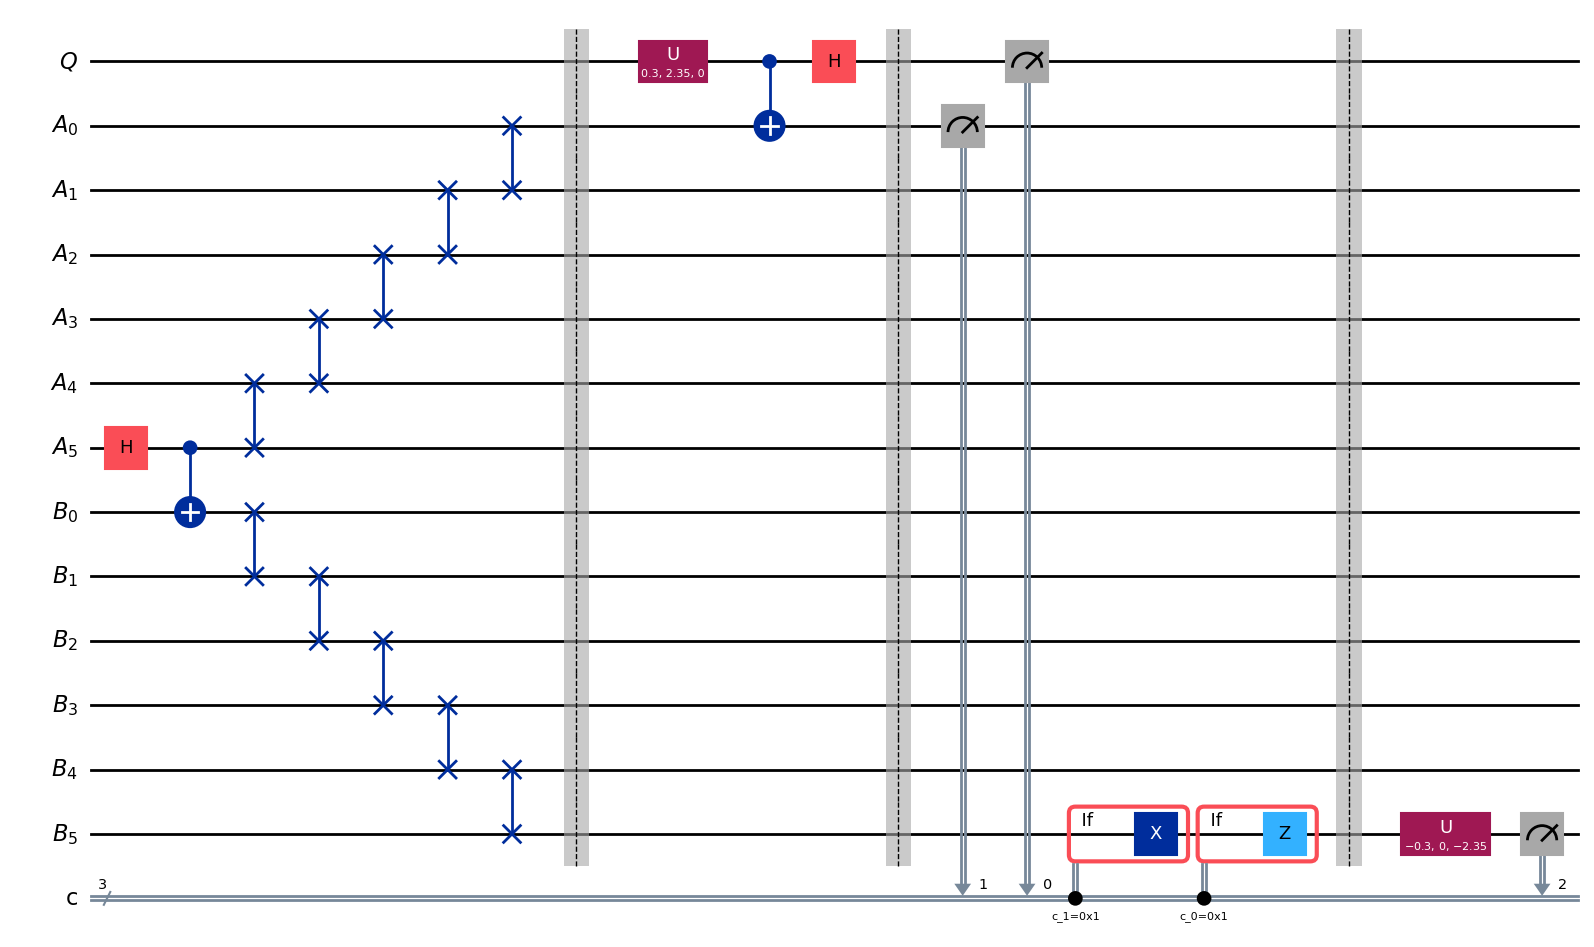

In [8]:
# Step 1: Map

# Define registers
qr = QuantumRegister(13, "q")

qc = QuantumCircuit(qr, cr)

# Define registers
secret = QuantumRegister(1, "Q")
ebitsa = QuantumRegister(6, "A")
ebitsb = QuantumRegister(6, "B")
# q = ClassicalRegister(1, "q meas")
# a = ClassicalRegister(1, "a")
# b = ClassicalRegister(1, "b")
cr = ClassicalRegister(3, "c")
qc = QuantumCircuit(secret, ebitsa, ebitsb, cr)

# We'll start Alice in the middle of the circuit, then move information outward in both directions.
Alice = 5
Bob = 0
qc.h(ebitsa[Alice])
qc.cx(ebitsa[Alice], ebitsb[Bob])

# Starting with Bob and Alice in the center, we swap their information onto adjacent qubits,
# until the information is on distant qubits.

for n in range(Alice):
    qc.swap(ebitsb[Bob], ebitsb[Bob + 1])
    qc.swap(ebitsa[Alice], ebitsa[Alice - 1])
    Alice = Alice - 1
    Bob = Bob + 1

qc.barrier()

# Create a random state for Alice (qubit zero)
np.random.seed(42)  # fixing seed for repeatability
# theta = np.random.uniform(0.0, 1.0) * np.pi    #from 0 to pi
theta = 0.3
varphi = np.random.uniform(0.0, 2.0) * np.pi  # from 0 to 2*pi


qc.u(theta, varphi, 0.0, secret)

# Entangle Alice's two qubits
qc.cx(secret, ebitsa[Alice])
qc.h(secret)

qc.barrier()

# Make measurements of Alice's qubits and store the results in the classical register.
qc.measure(ebitsa[Alice], cr[1])
qc.measure(secret, cr[0])

# Send instructions to Bob's qubits based on the outcome of Alice's measurements.
with qc.if_test((cr[1], 1)):
    qc.x(ebitsb[Bob])
with qc.if_test((cr[0], 1)):
    qc.z(ebitsb[Bob])

qc.barrier()

# Invert the preparation we did for Carl's qubit so we can check whether we did this correctly.
qc.u(theta, varphi, 0.0, ebitsb[Bob]).inverse()  # inverse of u(theta,varphi,0.0)
qc.measure(ebitsb[Bob], cr[2])  # add measurement gate

qc.draw("mpl")

### Transpilation Without Optimization

For this experiment, the circuit is transpiled with optimization level `0`.

This preserves the SWAP operations more explicitly, allowing us to observe the additional hardware operations required to distribute the entangled qubits across the processor.

In [9]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pmzero = generate_preset_pass_manager(target=target, optimization_level=0)

qc_isa_zero = pmzero.run(qc)

print(qc_isa_zero.depth())

55


In [10]:
job = sampler.run([qc_isa_zero])
# job = sampler_sim.run([qc_isa_zero])
counts = job.result()[0].data.c.get_counts()

### Results After Separating the Entangled Qubits

The teleportation protocol is again executed on real IBM Quantum hardware.

The results show a slightly higher error rate compared with the first experiment. The additional SWAP operations increase the number of physical operations required, giving the hardware more opportunities for noise and gate errors to affect the computation.

Despite these errors, the dominant measurement outcome still demonstrates the underlying teleportation protocol.

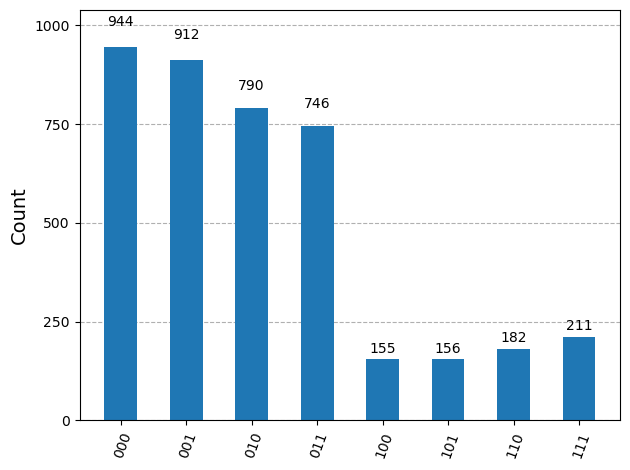

In [11]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

# Conclusion

This experiment demonstrates quantum teleportation on real quantum hardware.

The key requirement is not a direct quantum connection between Alice and Bob. Instead, the protocol relies on:

1. A shared entangled qubit pair.
2. Alice's measurements of the unknown state and her entangled qubit.
3. Classical communication of those measurement results.
4. Conditional quantum operations performed by Bob.

The second experiment shows that the entangled qubits can be moved apart across a processor using SWAP operations while the teleportation protocol remains valid. The increased errors observed on hardware highlight the effect of additional physical operations and noise.

Thus, quantum teleportation transfers the quantum state, not the physical qubit itself, using entanglement together with classical communication.